# Full experiment - audience demo - whispy in ~7 minutes

> **Live-presentation demo.** One notebook that walks a volunteer from the
> audience through a complete listening experiment and shows the data being
> collected along the way. It chains all five whispy UI types:
> **InfoWindow → Questionnaire → NAFC (adaptive staircase) → ABX → ScaleTest**.

Timing plan (~6–8 minutes total):

| step | UI | config | time |
|---|---|---|---|
| 1. Welcome | `InfoWindow` | `demo_configs/welcome_demo.yml` | ~30 s |
| 2. Consent + participant ID | `Questionnaire` | `questionnaires/questionnaire_consent.yml` | ~1–2 min |
| 3. Staircase 2-AFC (pitch) | `NAFC` + `whispy.Staircase` | `demo_configs/staircase_demo.yml` | ~3–4 min |
| 4. ABX (2 trials) | `ABX` | `demo_configs/abx_demo.yml` | ~1 min |
| 5. Movie-quote scales (3 quotes) | `ScaleTest` | `demo_configs/scale_testing_demo.yml` | ~1 min |
| 6. Thank you | `InfoWindow` | `demo_configs/thanks_demo.yml` | ~15 s |

All demo configs live in [`configs/demo_configs/`](../configs/demo_configs/);
the WAVs live in `examples/demo_stimuli/audience_demo/` (regenerate with
`python examples/demo_stimuli/audience_demo/generate_audience_demo_stimuli.py`).
The shared look comes from [`configs/design.yml`](../configs/design.yml). As in
every whispy experiment: **to change the demo, edit the YAML - not the Python.**

**Presenter tips**

- Run each cell right before its step, so the audience sees the
  code → window → data cycle; every block prints its results DataFrame and the
  CSV file it saved.
- **Rehearse once without an audience:** running the three setup cells
  validates every WAV (existence, clipping, one sampling rate) when the
  `SoundDevice` handler loads, and the optional simulation cell dry-runs the
  staircase without a GUI.
- If you haven't installed the project yet, run `pip install -e .` from the
  repo root.

## 1 · Welcome the audience (~30 s)

A fullscreen greeting before anything else; its message lives in
[`configs/demo_configs/welcome_demo.yml`](../configs/demo_configs/welcome_demo.yml)
(markdown supported), so you can reword it without editing the Python. The
cell blocks until the volunteer clicks **Continue**.

In [1]:
from pathlib import Path
from whispy.ui import InfoWindow
from whispy.utils import read_config

# The welcome message lives in configs/demo_configs/welcome_demo.yml
# (markdown supported); reword it there without editing this cell.
welcome = read_config(Path('..') / 'configs' / 'demo_configs' / 'welcome_demo.yml')['ui']
InfoWindow(welcome['message'], fullscreen=welcome.get('fullscreen', True), blocking=True)

## 2 · Consent & anonymous participant ID (~1–2 min)

The consent questionnaire
([`configs/questionnaires/questionnaire_consent.yml`](../configs/questionnaires/questionnaire_consent.yml))
records consent and builds an **anonymous participant id** from the
`pid_1..pid_4` answers (e.g. `HPo1`). The id is kept **in memory** in the
`participant_id` variable and baked into the *name* of every CSV saved below -
point this out to the audience: no name is ever stored, yet all of one
person's files share one id.

In [2]:
from pathlib import Path
from whispy.ui import Questionnaire
from whispy.utils import participant_id_from_consent, save_results

consent_config = Path('..') / 'configs' / 'questionnaires' / 'questionnaire_consent.yml'
consent = Questionnaire(questionnaire=consent_config, blocking=True)
consent_results = consent.get_results()
consent.close()

# Anonymous participant id (e.g. 'HPo1'); names every result file below.
participant_id = participant_id_from_consent(consent_results)
print('anonymous participant id:', participant_id)

consent_path = save_results(consent_results, 'audience_demo_consent',
                            participant_id=participant_id)
print('saved consent to        :', consent_path.name)
consent_results

anonymous participant id: HPo1
saved consent to        : audience_demo_consent_HPo1_20260712_173048.csv


,section,question,prompt,type,required,answer
0,pid,pid_1,1.1 Enter the first letter of your mother's na...,text,True,H
1,pid,pid_2,1.2 Enter the first letter of your father's na...,text,True,P
2,pid,pid_3,1.3 Enter the last letter of your name (e.g. *...,text,True,o
3,pid,pid_4,1.4 Enter the second digit of your birthday (e...,text,True,1
4,consent,id_1,2.1 I agree that my anonymous ratings can be p...,single_choice,True,Yes (continue with the listening experiment)
5,consent,withdrawal,2.2 I understand that I can withdraw my consen...,single_choice,True,Yes
6,listening_test_subject_hours,matriculation_number,3.1 Are you studying in the Audio Communicatio...,single_choice,True,123456.0


## 3 · Adaptive staircase - find your pitch threshold (~3–4 min)

A **2-AFC frequency-discrimination staircase**
([`configs/demo_configs/staircase_demo.yml`](../configs/demo_configs/staircase_demo.yml)):
on every trial one interval plays the **1000 Hz reference**, the other a
slightly **higher tone**, and the volunteer picks the higher one. The test
starts easy at **1100 Hz** and narrows toward 1000 Hz - two correct answers
in a row make it harder, one mistake makes it easier (1-up/2-down, converging
on ~70.7% correct). The run is capped at **14 trials** to stay under 4
minutes.

The target ids in the config are the **frequency offset in Hz**, so
`staircase.threshold()` at the end reports the volunteer's just-noticeable
difference directly in Hz - a nice live payoff for the audience.

In [3]:
import whispy
from pathlib import Path
from whispy.interfaces import SoundDevice
from whispy.ui import NAFC
from whispy.utils import read_config

config_path = Path('..') / 'configs' / 'demo_configs' / 'staircase_demo.yml'
stimuli_dir = Path('demo_stimuli/audience_demo')   # <- folder with the demo WAVs

cfg = read_config(config_path)
handler = SoundDevice(config_path, stimuli_dir, loop=False)   # reads SoundDevice:
print('available stimulus ids (0 = reference, rest = Hz above 1000 Hz):')
print('  ', list(handler.stimuli.keys()))

available stimulus ids (0 = reference, rest = Hz above 1000 Hz):
   [0, 2, 4, 8, 15, 25, 40, 60, 100]


In [4]:
trial = cfg['trial']
levels = trial['levels']
n_intervals = int(cfg['test']['n_choices'])

def build_screen(level):
    return {
        'test': [trial['standard']] * (n_intervals - 1) + [level],
        'correct': level,
        'task': trial['task'],
        'block': 0,
        'section': 0,
        'block_name': trial.get('block_name', 'Staircase'),
        'section_name': trial.get('section_name', 'N-AFC'),
    }

sc_kwargs = dict(cfg['staircase'])
if sc_kwargs.get('start_index', 0) < 0:          # allow -1 = easiest (last) level
    sc_kwargs['start_index'] += len(levels)

staircase = whispy.Staircase(levels, build_screen=build_screen, **sc_kwargs)
print(f'starting level: +{staircase.current_level} Hz '
      f'(a {1000 + staircase.current_level} Hz tone vs the 1000 Hz reference)')
print(f'stops after {sc_kwargs["max_reversals"]} reversals '
      f'or {sc_kwargs["max_trials"]} trials, whichever comes first')

starting level: +100 Hz (a 1100 Hz tone vs the 1000 Hz reference)
stops after 6 reversals or 14 trials, whichever comes first


### Optional - dry-run the staircase without a GUI

**Skip this cell during the live demo.** It replaces the window with a
simulated listener so you can rehearse the timing and check that the
`staircase:` settings converge within the 14-trial cap.

In [5]:
import numpy as np

rng = np.random.default_rng(0)

# Simulated listener: p(correct) ramps from just above chance (hardest level)
# to near-certain (easiest level).
chance = 1.0 / n_intervals
p_values = np.linspace(chance + 0.05, 0.98, len(levels))
p_correct = {level: float(p) for level, p in zip(levels, p_values)}

sim = whispy.Staircase(levels, build_screen=build_screen, **sc_kwargs)
sim_results = sim.run(lambda screen: bool(rng.random() < p_correct[screen['correct']]))
print(f'simulated run: {len(sim_results)} trials, {sim.n_reversals} reversals, '
      f'threshold ~ +{sim.threshold():.0f} Hz')

simulated run: 14 trials, 5 reversals, threshold ~ +70 Hz


### Run it (the volunteer takes over here)

One window is reused for the whole staircase (the first trial opens it, later
trials swap their content into the same window via `parent=host`). Both
intervals **autoplay** at the start of each trial; the volunteer can replay
with keys **1/2** (or click), picks the **higher** tone, and presses **Enter**.

In [6]:
host = None

def run_trial(screen):
    global host
    naf = NAFC(screen=screen, stimuli_handler=handler,
               n_afc_config=config_path, blocking=True, parent=host)
    if host is None:
        host = naf            # first trial owns the shared window
    return bool(naf.get_results()['correct_bool'].iloc[0])

try:
    staircase_results = staircase.run(run_trial)
finally:
    if host is not None:
        host.close()

print('trials             :', len(staircase_results))
print('reversals          :', staircase.n_reversals)
print('reversal levels    :', staircase.reversal_levels(), '(Hz above 1000 Hz)')
threshold = staircase.threshold()
if threshold is not None:
    print(f'estimated threshold: ~+{threshold:.0f} Hz - you can tell '
          f'{1000 + threshold:.0f} Hz from 1000 Hz '
          f'(a {threshold / 10:.1f}% frequency difference)')
staircase_results

trials             : 14
reversals          : 4
reversal levels    : [40, 100, 4, 15] (Hz above 1000 Hz)
estimated threshold: ~+40 Hz - you can tell 1040 Hz from 1000 Hz (a 4.0% frequency difference)


,trial,level_index,level,correct,step,reversal,rt
0,1,7,100,True,,False,12.559853
1,2,7,100,True,down,False,10.810330
2,3,5,40,False,up,True,4.111427
3,4,7,100,True,,False,13.456305
4,5,7,100,True,down,True,2.366488
5,6,5,40,True,,False,4.300469
6,7,5,40,True,down,False,2.832162
7,8,3,15,True,,False,2.900776
8,9,3,15,True,down,False,3.900194
9,10,1,4,False,up,True,3.612761


In [7]:
from whispy.utils import save_results

# `participant_id` was set by the consent block above; if you skipped it, the
# file name falls back to an iterating number instead.
participant_id = globals().get('participant_id')
staircase_path = save_results(staircase_results, 'audience_demo_staircase',
                              participant_id=participant_id)
print('saved staircase results to', staircase_path.name)

saved staircase results to audience_demo_staircase_HPo1_20260712_173236.csv


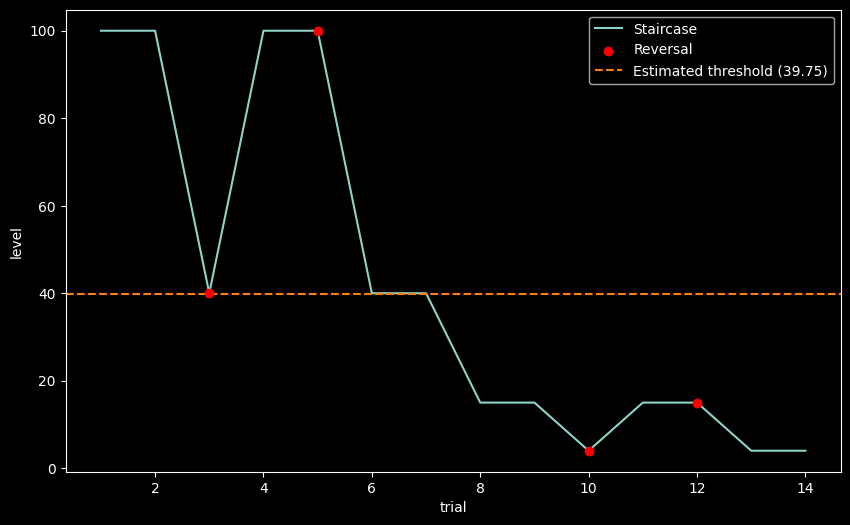

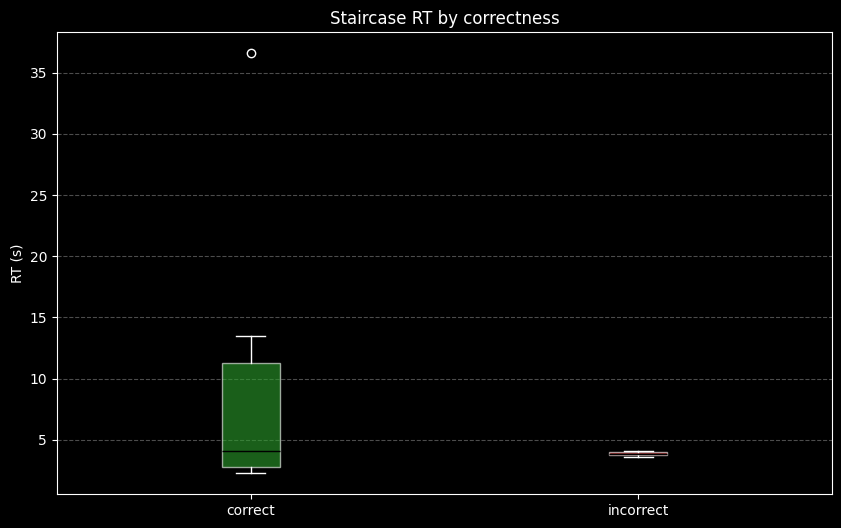

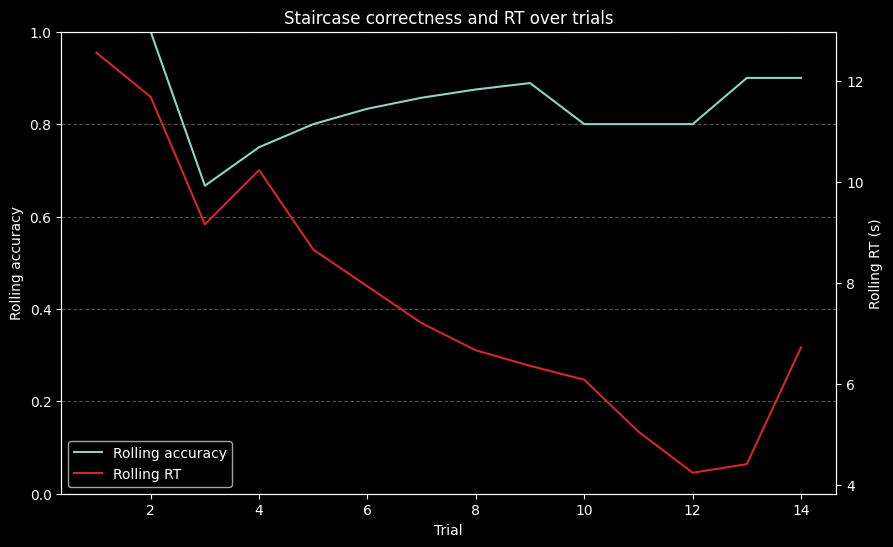

In [8]:
from whispy.utils import Plotting as plt

## Plot the staircase results
plt().plot_staircase(staircase_results, threshold=staircase.threshold(), plot_name="audience_demo_staircase")
plt().plot_staircase_rt_boxplot(staircase_results, plot_name="audience_demo_staircase_rt_boxplot")
plt().plot_staircase_correctness_rt_over_trials(staircase_results, plot_name="audience_demo_staircase_correctness_rt_over_trials")

## 4 · ABX - is X the same as A or B? (~1 min)

Two quick, clearly different comparisons
([`configs/demo_configs/abx_demo.yml`](../configs/demo_configs/abx_demo.yml)):
a **major vs. minor chord** ("happy vs. sad") and a **steady vs. vibrato
tone**. One presentation each → 2 trials, mainly to show off the ABX window:
**A**, **B**, **X** playback buttons on top, the A/B answer below. Chance is
50% - with pairs this obvious the volunteer should score 100%.

In [9]:
import pandas as pd
from pathlib import Path
from whispy.interfaces import SoundDevice
from whispy.ui import ABX
from whispy.utils import read_config

abx_config_path = Path('..') / 'configs' / 'demo_configs' / 'abx_demo.yml'
stimuli_dir = Path('demo_stimuli/audience_demo')

abx_cfg = read_config(abx_config_path)
abx_handler = SoundDevice(abx_config_path, stimuli_dir, loop=False)
print('available stimulus ids:', list(abx_handler.stimuli.keys()))

available stimulus ids: ['major_chord', 'minor_chord', 'steady_tone', 'vibrato_tone']


In [10]:
import random

exp = abx_cfg['experiment']
abx_trial = abx_cfg['trial']
rng = random.Random(exp.get('seed', 0))

abx_trials = []
for pair in abx_cfg['pairs']:
    for _ in range(int(exp.get('repetitions', 1))):
        t = dict(pair)
        t['x'] = rng.choice([pair['a'], pair['b']])   # which stimulus X copies
        abx_trials.append(t)
if exp.get('shuffle_trials', True):
    rng.shuffle(abx_trials)

def build_abx_screen(pair, trial_index):
    return {
        'a': pair['a'], 'b': pair['b'], 'x': pair['x'],
        'task': abx_trial['task'],
        'block': 0, 'section': 0,
        'trial_id': trial_index,
        'block_name': abx_trial.get('block_name', 'ABX'),
        'section_name': pair.get('name', 'pair'),
        # drives the "Trial X of Y" progress bar (ui.show_progress)
        'progress': {'current': trial_index, 'total': len(abx_trials)},
    }

print(f"{len(abx_trials)} trials "
      f"({len(abx_cfg['pairs'])} pairs x {exp.get('repetitions')} repetition(s))")

2 trials (2 pairs x 1 repetition(s))


### Run it

Press **A**, **B**, **X** (or click) to hear each interval, choose the match
with **←/→** (or click A/B), then press **Enter** to submit. One window is
reused for both trials.

In [11]:
host = None

def run_abx_trial(screen):
    global host
    abx = ABX(screen=screen, stimuli_handler=abx_handler,
              abx_config=abx_config_path, blocking=True, parent=host)
    if host is None:
        host = abx            # first trial owns the shared window
    return abx.get_results()

rows = []
try:
    for i, pair in enumerate(abx_trials, start=1):
        rows.append(run_abx_trial(build_abx_screen(pair, i)))
finally:
    if host is not None:
        host.close()

abx_results = pd.concat(rows, ignore_index=True)
overall = abx_results['correct_bool'].mean()
print(f'percent correct: {overall * 100:.0f}%  (n={len(abx_results)}, chance=50%)')
abx_results

percent correct: 50%  (n=2, chance=50%)


,block,section,trial_id,block_name,section_name,a,b,x,correct,selected,correct_bool,rt
0,0,0,1,Audience demo,happy vs sad chord,minor_chord,major_chord,minor_chord,A,B,False,21.095154
1,0,0,2,Audience demo,steady vs vibrato,steady_tone,vibrato_tone,steady_tone,A,A,True,6.452774


In [12]:
from whispy.utils import save_results

participant_id = globals().get('participant_id')
abx_path = save_results(abx_results, 'audience_demo_abx',
                        participant_id=participant_id)
print('saved ABX results to', abx_path.name)

saved ABX results to audience_demo_abx_HPo1_20260712_173304.csv


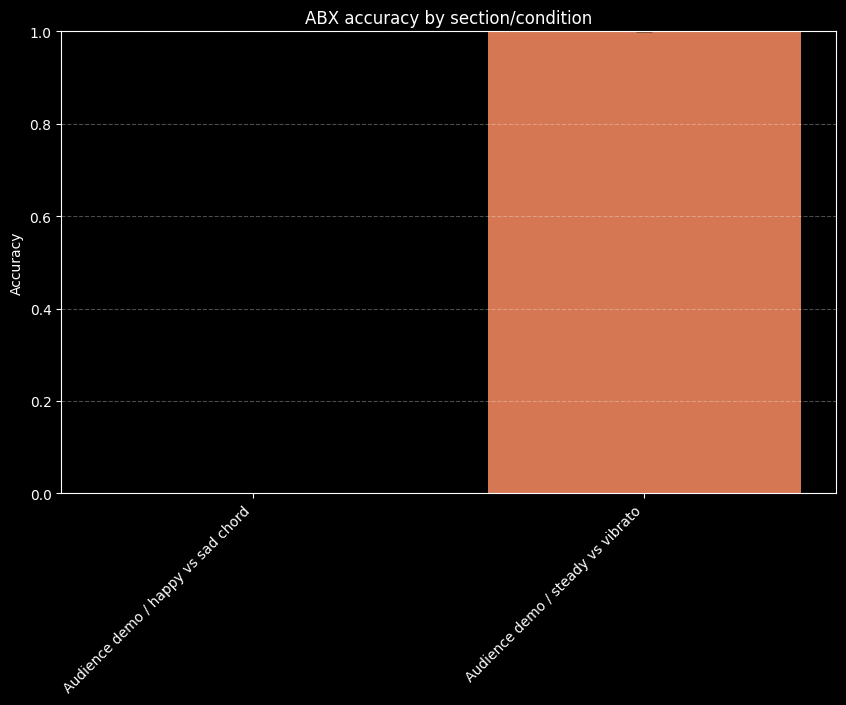

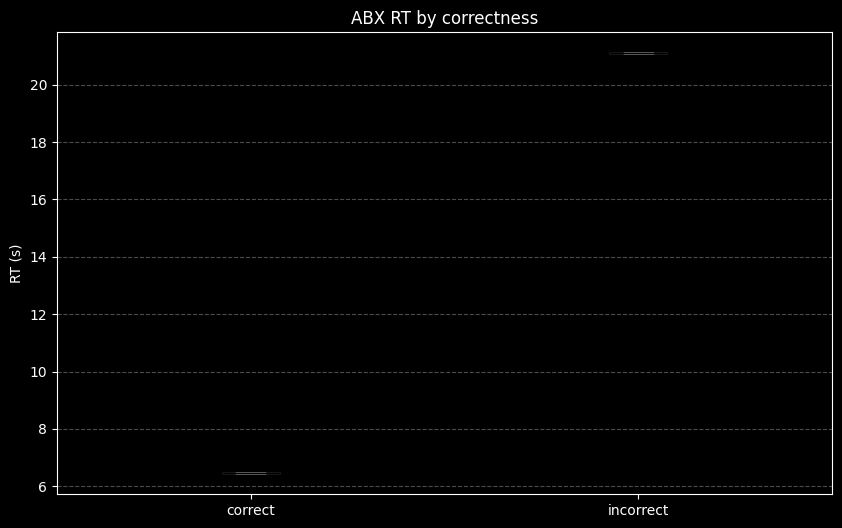

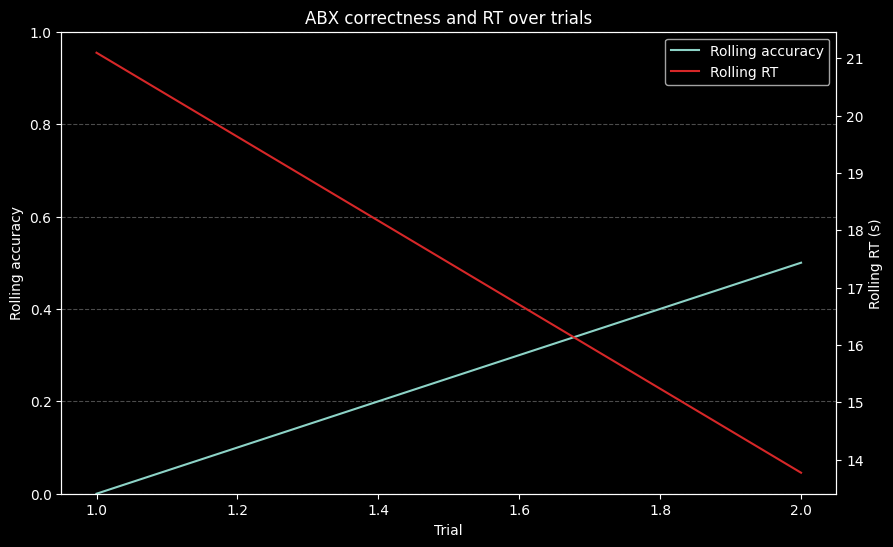

In [13]:
from whispy.utils import Plotting as plt

plt().plot_abx_accuracy_by_section(abx_results, plot_name="audience_demo_abx_accuracy_by_section")
plt().plot_abx_rt_boxplot(abx_results, plot_name="audience_demo_abx_rt_boxplot")
plt().plot_abx_correctness_rt_over_trials(abx_results, plot_name="audience_demo_abx_correctness_rt_over_trials")

## 5 · Scale testing - rate the movie quotes (~1 min)

Three famous movie quotes - **Reservoir Dogs**, Forrest Gump's **box of
chocolates** and Captain **Jack Sparrow** - each rated on its own set of
scales
([`configs/demo_configs/scale_testing_demo.yml`](../configs/demo_configs/scale_testing_demo.yml)):
the Reservoir Dogs quote gets 5 questions, the box of chocolates 3 and Jack
Sparrow 1, mixing every scale widget whispy offers (Likert buttons, slider,
bipolar scale). The scheduler randomizes the order; each screen presents one
stimulus.

In [14]:
import whispy
from pathlib import Path
from whispy.interfaces import SoundDevice
from whispy.ui import ScaleTest
from whispy.utils import read_config

scale_config_path = Path('..') / 'configs' / 'demo_configs' / 'scale_testing_demo.yml'
stimuli_dir = Path('demo_stimuli/audience_demo')

scale_cfg = read_config(scale_config_path)
scale_handler = SoundDevice(scale_config_path, stimuli_dir, loop=False)
print('available stimulus ids:', list(scale_handler.stimuli.keys()))

available stimulus ids: ['reservoir_dogs', 'box_of_chocolates', 'jack_sparrow']


In [15]:
scheduler = whispy.ExperimentScheduler(experiment=scale_cfg['experiment'])

# If per_stimulus_questions are defined, use those; otherwise use global questions.
# Pass them on the screen dict so ScaleTest can use stimulus-specific scales.
per_stim_q = scale_cfg.get('per_stimulus_questions')

screens = []
for section_screen in scheduler:
    for stimulus in list(section_screen['test']):
        screen = {
            'stimulus': stimulus,
            'task': scale_cfg['trial']['task'],
            'block': section_screen['block'],
            'section': section_screen['section'],
            'block_name': section_screen['block_name'],
            'section_name': section_screen['section_name'],
        }
        # Wire up per-stimulus questions if defined
        if per_stim_q is not None and isinstance(per_stim_q, dict):
            screen['questions'] = per_stim_q.get(stimulus, scale_cfg.get('questions'))
        screens.append(screen)

for i, screen in enumerate(screens, start=1):
    screen['trial_id'] = i
    # drives the "Trial X of Y" progress bar (ui.show_progress)
    screen['progress'] = {'current': i, 'total': len(screens)}

print(f'{len(screens)} screens (one stimulus each):',
      [screen['stimulus'] for screen in screens])

3 screens (one stimulus each): [np.str_('jack_sparrow'), np.str_('box_of_chocolates'), np.str_('reservoir_dogs')]


### Run it

Press **Space** (or click **Play**) to hear the sound, answer every scale,
then press **Enter** to submit. One window is reused for both screens.

In [16]:
host = None
scale_results = None

try:
    for screen in screens:
        scale_test = ScaleTest(screen=screen, stimuli_handler=scale_handler,
                               scale_test_config=scale_config_path,
                               blocking=True, parent=host)
        if host is None:
            host = scale_test    # first screen owns the shared window
        scale_results = scale_test.get_results(scale_results)
finally:
    if host is not None:
        host.close()

print('mean answer per stimulus and question:')
print(scale_results.pivot_table(index='stimulus', columns='question',
                                values='answer', aggfunc='mean')
      .round(1).to_string())
scale_results

mean answer per stimulus and question:
question           agreement  familiarity  funniness  intensity  outrage  recognizability  sentimentality  tipping  wisdom
stimulus                                                                                                                  
box_of_chocolates        4.0          NaN        NaN        NaN      NaN              NaN            76.0      NaN     2.0
jack_sparrow             NaN          NaN        NaN        NaN      NaN              6.0             NaN      NaN     NaN
reservoir_dogs           NaN          3.0       93.0        1.0      7.0              NaN             NaN      3.0     NaN


,block,section,trial_id,block_name,section_name,stimulus,question,prompt,scale_type,interaction_method,scale_min,scale_max,answer,rt
0,0,0,1,movie quotes,famous quotes,jack_sparrow,recognizability,How **recognizable** is this movie quote?,likert,buttons,1,7,6,32.770093
1,0,0,2,movie quotes,famous quotes,box_of_chocolates,sentimentality,How **sentimental** does this quote feel?,continuous,slider,0,100,76,29.471396
2,0,0,2,movie quotes,famous quotes,box_of_chocolates,wisdom,How much **life wisdom** is in this quote?,likert,buttons,1,5,2,29.471396
3,0,0,2,movie quotes,famous quotes,box_of_chocolates,agreement,Is life really like a box of chocolates?,bipolar,buttons,-5,5,4,29.471396
4,0,0,3,movie quotes,famous quotes,reservoir_dogs,outrage,How **scandalous** is refusing to tip?,likert,buttons,1,7,7,36.365475
5,0,0,3,movie quotes,famous quotes,reservoir_dogs,funniness,How **funny** is this exchange?,continuous,slider,0,100,93,36.365475
6,0,0,3,movie quotes,famous quotes,reservoir_dogs,tipping,And you? Do you **believe** in tipping?,bipolar,buttons,-5,5,3,36.365475
7,0,0,3,movie quotes,famous quotes,reservoir_dogs,intensity,How **heated** does this exchange feel?,likert,buttons,1,5,1,36.365475
8,0,0,3,movie quotes,famous quotes,reservoir_dogs,familiarity,How often have you **seen or heard** this scen...,likert,buttons,1,5,3,36.365475


In [17]:
from whispy.utils import save_results

participant_id = globals().get('participant_id')
scales_path = save_results(scale_results, 'audience_demo_scales',
                           participant_id=participant_id)
print('saved scale-testing results to', scales_path.name)

saved scale-testing results to audience_demo_scales_HPo1_20260712_173444.csv


## 6 · Thank the volunteer (~15 s)

The closing message lives in
[`configs/demo_configs/thanks_demo.yml`](../configs/demo_configs/thanks_demo.yml)
(markdown supported).

In [18]:
from pathlib import Path
from whispy.ui import InfoWindow
from whispy.utils import read_config

thanks = read_config(Path('..') / 'configs' / 'demo_configs' / 'thanks_demo.yml')['ui']
InfoWindow(thanks['message'], fullscreen=thanks.get('fullscreen', True), blocking=True)

## The data trail - show this to the audience

Every block above saved one CSV into `examples/results/`, all named with the
same anonymous participant id and a timestamp (files are never overwritten).
This cell lists this volunteer's files - the complete data trail of the
experiment they just took.

In [19]:
from pathlib import Path

files = sorted(Path('results').glob('audience_demo_*.csv'))
plots = sorted(Path('results/plots').glob('audience_demo_*.png'))
participant_id = globals().get('participant_id')
if participant_id:
    files = [f for f in files if f'_{participant_id}_' in f.name]

print(f"result files for participant {participant_id or '(no id)'}:")
for f in files:
    print('  ', f.name)

print("\nresult plots:")
for p in plots:
    print('  ', p.name)

result files for participant HPo1:
   audience_demo_abx_HPo1_20260712_170302.csv
   audience_demo_abx_HPo1_20260712_173304.csv
   audience_demo_consent_HPo1_20260712_170103.csv
   audience_demo_consent_HPo1_20260712_173048.csv
   audience_demo_scales_HPo1_20260712_170413.csv
   audience_demo_scales_HPo1_20260712_173444.csv
   audience_demo_staircase_HPo1_20260712_170232.csv
   audience_demo_staircase_HPo1_20260712_173236.csv

result plots:
   audience_demo_abx_accuracy_by_section_20260712_163325.png
   audience_demo_abx_accuracy_by_section_20260712_163429.png
   audience_demo_abx_accuracy_by_section_20260712_170302.png
   audience_demo_abx_accuracy_by_section_20260712_173304.png
   audience_demo_abx_correctness_rt_over_trials_20260712_163326.png
   audience_demo_abx_correctness_rt_over_trials_20260712_163430.png
   audience_demo_abx_correctness_rt_over_trials_20260712_170302.png
   audience_demo_abx_correctness_rt_over_trials_20260712_173305.png
   audience_demo_abx_rt_boxplot_20260712